# 🐧 Penguin Species Classification: ML for Biodiversity Monitoring & Biosecurity

**Author:** Dean | Lead Data & AI Engineer  
**Focus:** Classifying penguin species from morphometric measurements to support Antarctic biodiversity research and biosecurity monitoring  
**Series:** Production ML Portfolio — Australian Government Policy Applications

---

## Executive Summary

This notebook demonstrates a production-grade ML pipeline for classifying penguin species (Adelie, Chinstrap, Gentoo) using body measurements including bill length, bill depth, flipper length, and body mass. The model supports **species identification automation**, **population monitoring**, and **biodiversity assessment**.

### Government Policy Context
- **AAD (Australian Antarctic Division)** — Antarctic species monitoring, climate impact assessment
- **DCCEEW** — Environment Protection and Biodiversity Conservation (EPBC) Act, threatened species
- **DAFF** — Biosecurity risk assessment, wildlife import/export (CITES compliance)
- **CSIRO** — Marine and Antarctic research, ecosystem modelling
- **Bureau of Meteorology** — Antarctic weather station network, climate change indicators

### Analytical Framework
| Prediction | Application | Stakeholder |
|-----------|-------------|-------------|
| Species ID (confident) | Automated census from morphometric data | AAD field researchers |
| Species ID (uncertain) | Flag for expert ornithologist review | CSIRO ecologists |
| Population trends | Climate change impact on species distribution | DCCEEW policy |
| Anomalous measurements | Potential hybrid or new subspecies detection | Biodiversity researchers |

---


## 1. Data Loading & Initial Assessment

In [1]:
import os, warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                             confusion_matrix, cohen_kappa_score)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
print("=" * 60)
print("ENVIRONMENT READY")
print("=" * 60)


ENVIRONMENT READY


In [2]:
data_path = None
for root, dirs, files in os.walk('/kaggle/input'):
    for f in files:
        full_path = os.path.join(root, f)
        print(f"  Found: {full_path}")
        if f.endswith('.csv') and data_path is None:
            data_path = full_path

if data_path is None:
    raise FileNotFoundError("No CSV found")

df = pd.read_csv(data_path)
print(f"\nUsing: {data_path}")
print(f"Loaded: {df.shape[0]:,} rows x {df.shape[1]} columns")


  Found: /kaggle/input/datasets/satyajeetrai/palmer-penguins-dataset-for-eda/penguins.csv

Using: /kaggle/input/datasets/satyajeetrai/palmer-penguins-dataset-for-eda/penguins.csv
Loaded: 344 rows x 9 columns


In [3]:
print("COLUMN SUMMARY")
print("=" * 80)
for i, col in enumerate(df.columns):
    dtype = df[col].dtype
    nuniq = df[col].nunique()
    nulls = df[col].isnull().sum()
    null_pct = f" ({nulls/len(df)*100:.1f}%)" if nulls > 0 else ""
    sample_val = df[col].dropna().iloc[0] if len(df[col].dropna()) > 0 else 'N/A'
    print(f"  {i:2d}. {col:25s} | {str(dtype):10s} | unique={nuniq:5d} | nulls={nulls}{null_pct}")
df.head()


COLUMN SUMMARY
   0. id                        | int64      | unique=  344 | nulls=0
   1. species                   | object     | unique=    3 | nulls=0
   2. island                    | object     | unique=    3 | nulls=0
   3. bill_length_mm            | float64    | unique=  164 | nulls=2 (0.6%)
   4. bill_depth_mm             | float64    | unique=   80 | nulls=2 (0.6%)
   5. flipper_length_mm         | float64    | unique=   55 | nulls=2 (0.6%)
   6. body_mass_g               | float64    | unique=   94 | nulls=2 (0.6%)
   7. sex                       | object     | unique=    2 | nulls=11 (3.2%)
   8. year                      | int64      | unique=    3 | nulls=0


,id,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


## 2. Target Variable Analysis

In [4]:
# Known target: 'species'
target_candidates = ['species', 'Species', 'target', 'Target', 'class', 'Class', 'label']
target_col = None
for candidate in target_candidates:
    if candidate in df.columns:
        target_col = candidate
        print(f"Found target: '{target_col}'")
        break

if target_col is None:
    for col in df.columns:
        if df[col].dtype == 'object' and df[col].nunique() <= 10:
            target_col = col
            print(f"Auto-detected: '{target_col}'")
            break

if target_col is None:
    raise ValueError("Could not identify target")

# Drop rows where target is NaN
df = df.dropna(subset=[target_col]).reset_index(drop=True)

print(f"\nRaw distribution:")
print(df[target_col].value_counts())

le_target = LabelEncoder()
df[target_col] = le_target.fit_transform(df[target_col].astype(str))
target_labels = list(le_target.classes_)
n_classes = len(target_labels)

print(f"\nEncoded: {dict(zip(range(n_classes), target_labels))}")
print(f"Classes: {n_classes}")


Found target: 'species'

Raw distribution:
species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64

Encoded: {0: 'Adelie', 1: 'Chinstrap', 2: 'Gentoo'}
Classes: 3


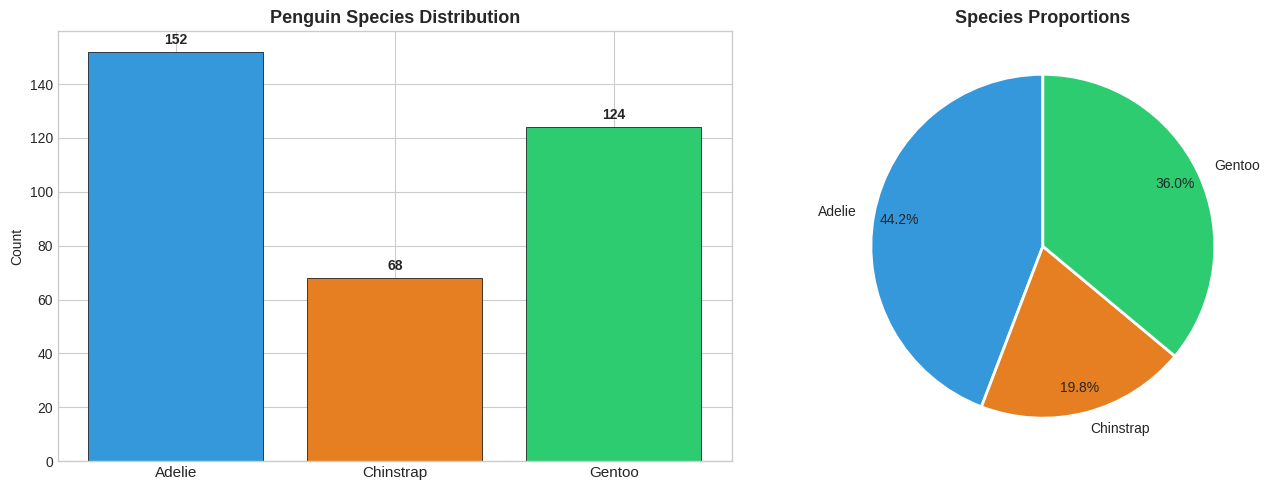

AU context: Australia operates 4 Antarctic research stations (Davis, Mawson, Casey, Macquarie).
AAD monitors penguin colonies as climate change indicators.
Antarctic Treaty System: Australia claims 42% of Antarctica (Australian Antarctic Territory).


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
vc = df[target_col].value_counts().sort_index()
colors = ['#3498db', '#e67e22', '#2ecc71'][:n_classes]
axes[0].bar(range(len(vc)), vc.values, color=colors, edgecolor='black', linewidth=0.5)
axes[0].set_xticks(range(len(vc)))
axes[0].set_xticklabels(target_labels, fontsize=11)
axes[0].set_title('Penguin Species Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(vc.values):
    axes[0].text(i, v + max(vc.values)*0.02, str(v), ha='center', fontweight='bold')
axes[1].pie(vc.values, labels=target_labels, autopct='%1.1f%%', colors=colors,
            startangle=90, pctdistance=0.85, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Species Proportions', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.savefig('target_distribution.png', dpi=150, bbox_inches='tight'); plt.show()
print("AU context: Australia operates 4 Antarctic research stations (Davis, Mawson, Casey, Macquarie).")
print("AAD monitors penguin colonies as climate change indicators.")
print("Antarctic Treaty System: Australia claims 42% of Antarctica (Australian Antarctic Territory).")


## 3. Exploratory Data Analysis

Key questions for biodiversity monitoring:
- Which morphometric features best distinguish species?
- Do island populations show different characteristics?
- Are there sex-based size differences within species?
- Can bill dimensions alone classify species reliably?


Numeric features (6): ['id', 'bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g', 'year']


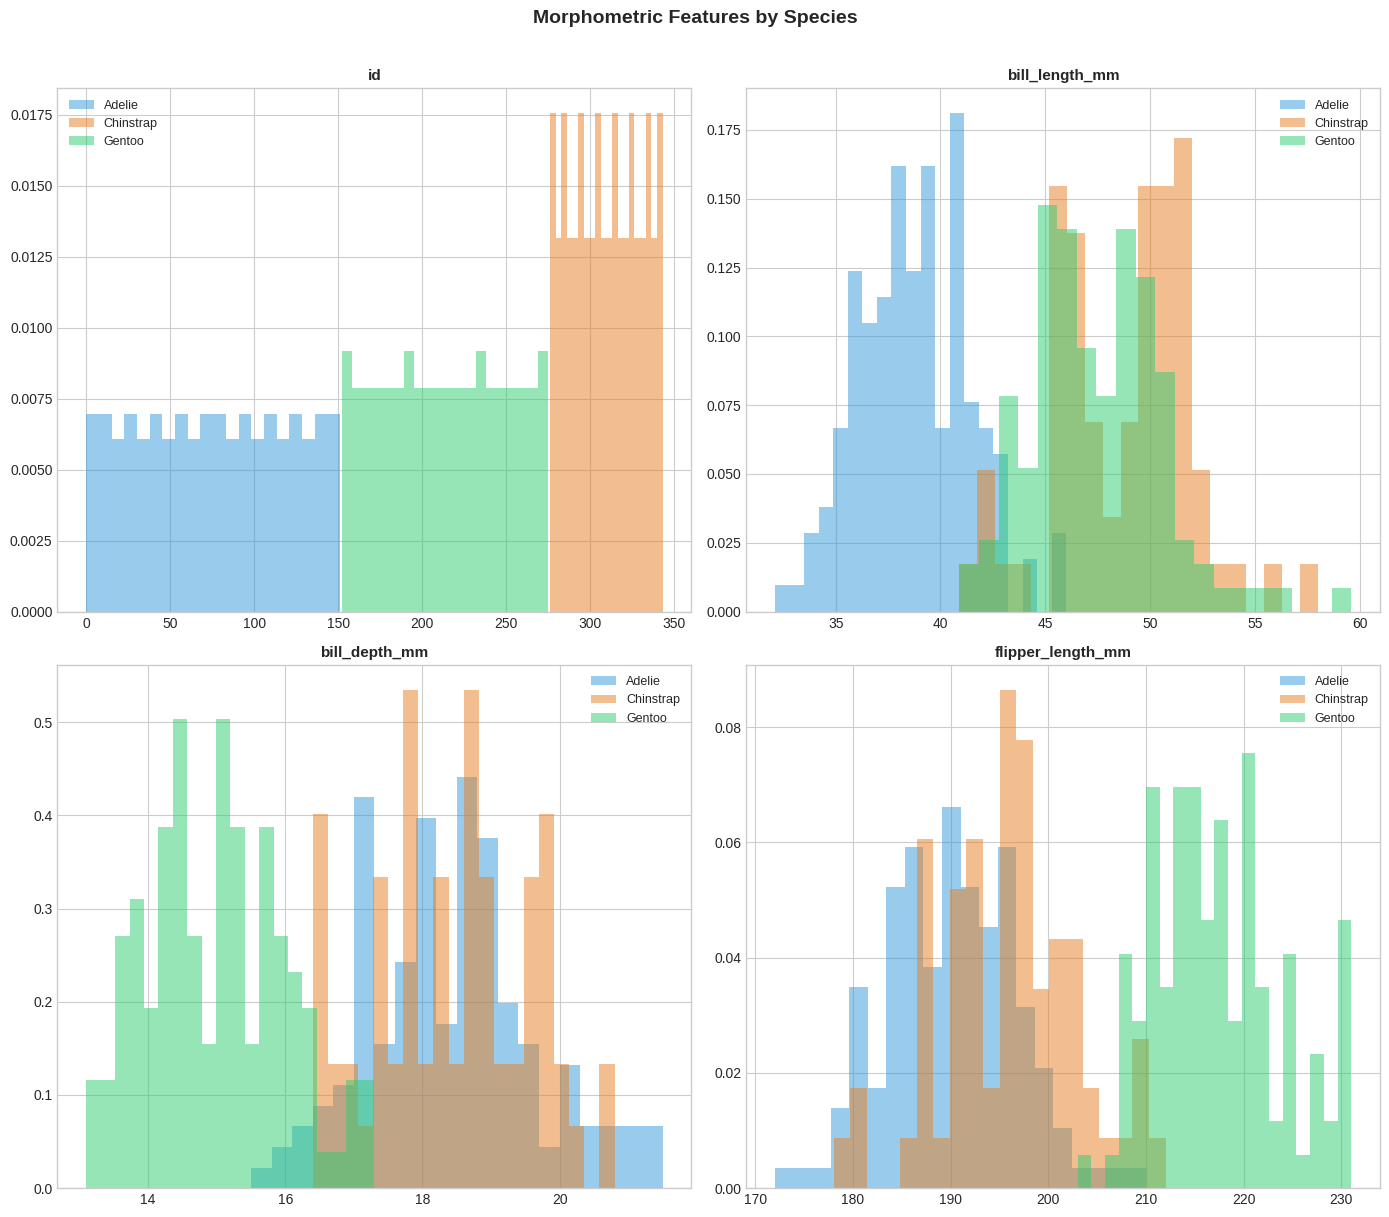

In [6]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if target_col in numeric_cols: numeric_cols.remove(target_col)
print(f"Numeric features ({len(numeric_cols)}): {numeric_cols}")

if len(numeric_cols) >= 2:
    fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    axes = axes.flatten()
    for i, col in enumerate(numeric_cols[:4]):
        for cls_val in sorted(df[target_col].unique()):
            subset = df[df[target_col] == cls_val][col].dropna()
            lbl = target_labels[cls_val]
            clr = colors[cls_val] if cls_val < len(colors) else None
            if len(subset) > 0:
                axes[i].hist(subset, bins=20, alpha=0.5, label=lbl, density=True, color=clr)
        axes[i].set_title(col, fontsize=11, fontweight='bold'); axes[i].legend(fontsize=9)
    plt.suptitle('Morphometric Features by Species', fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout(); plt.savefig('feature_distributions.png', dpi=150, bbox_inches='tight'); plt.show()


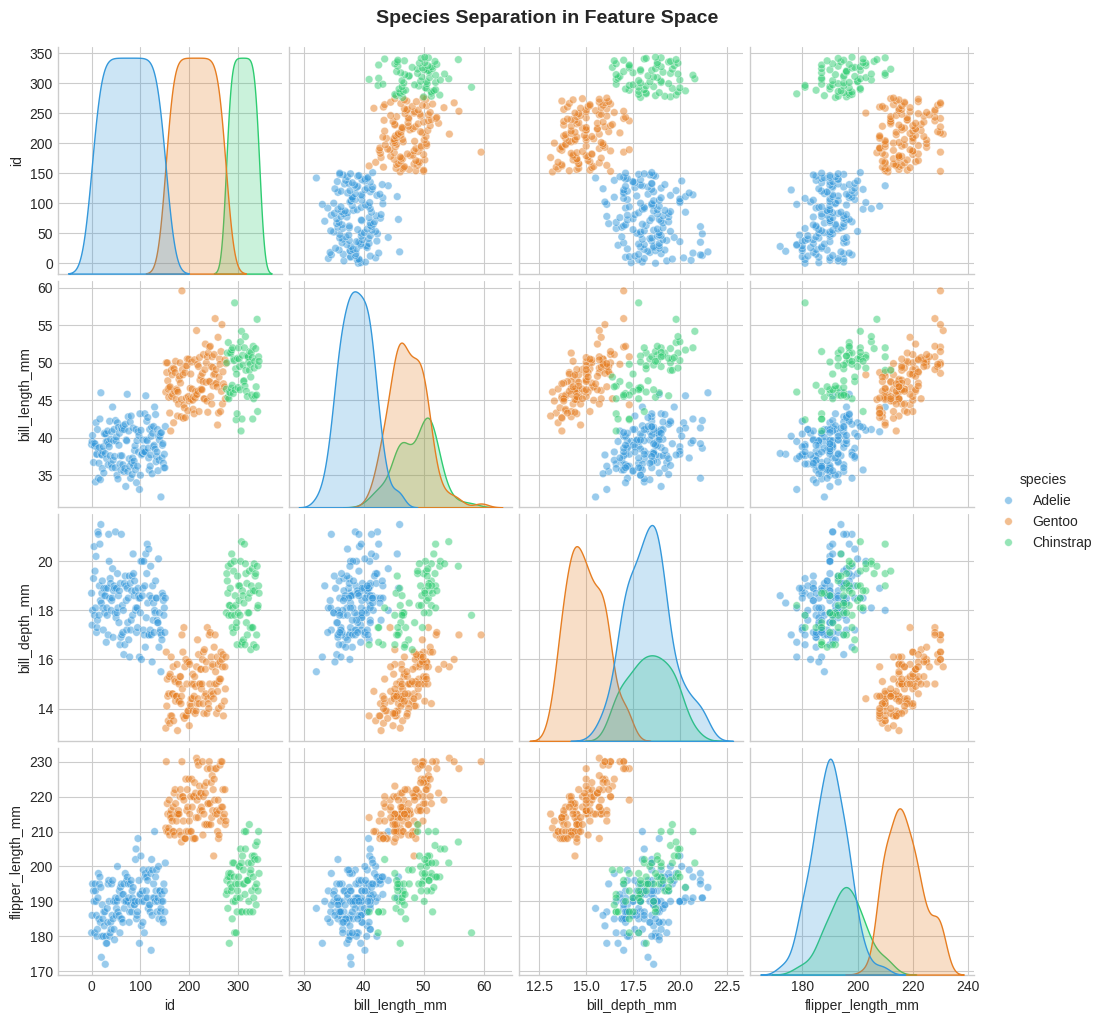

In [7]:
# Pairplot of key measurements
if len(numeric_cols) >= 2:
    plot_df = df[numeric_cols[:4] + [target_col]].dropna().copy()
    plot_df[target_col] = plot_df[target_col].map(dict(enumerate(target_labels)))
    g = sns.pairplot(plot_df, hue=target_col, palette=colors[:n_classes], diag_kind='kde',
                     plot_kws={'alpha': 0.5, 's': 30})
    g.fig.suptitle('Species Separation in Feature Space', fontsize=14, fontweight='bold', y=1.02)
    plt.savefig('pairplot.png', dpi=150, bbox_inches='tight'); plt.show()


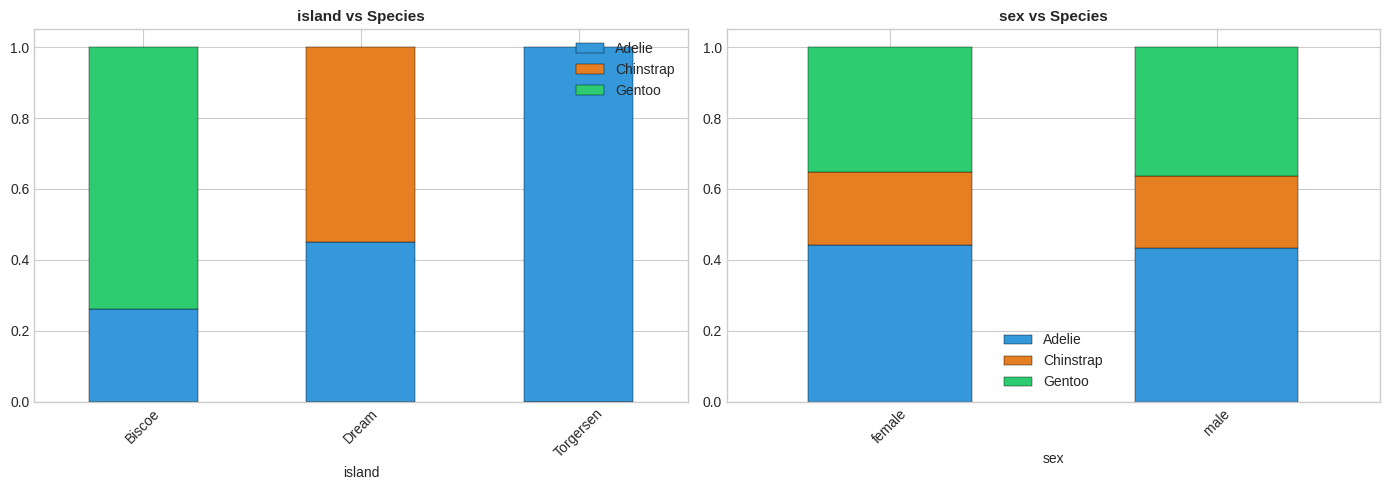

In [8]:
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
if target_col in cat_cols: cat_cols.remove(target_col)
cat_cols = [c for c in cat_cols if df[c].nunique() <= 10]

if len(cat_cols) > 0:
    fig, axes = plt.subplots(1, min(len(cat_cols), 3), figsize=(7 * min(len(cat_cols), 3), 5))
    if not isinstance(axes, np.ndarray): axes = [axes]
    for i, col in enumerate(cat_cols[:3]):
        ct = pd.crosstab(df[col], df[target_col], normalize='index')
        ct.columns = target_labels[:len(ct.columns)]
        ct.plot(kind='bar', stacked=True, ax=axes[i], color=colors, edgecolor='black', linewidth=0.3)
        axes[i].set_title(f'{col} vs Species', fontsize=11, fontweight='bold')
        axes[i].tick_params(axis='x', rotation=45)
    plt.tight_layout(); plt.savefig('categorical_analysis.png', dpi=150, bbox_inches='tight'); plt.show()


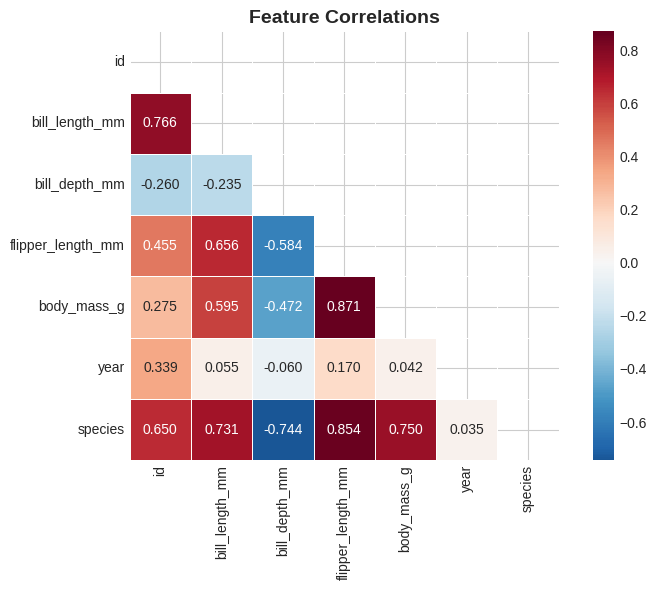

In [9]:
if len(numeric_cols) > 1:
    corr = df[numeric_cols + [target_col]].corr()
    fig, ax = plt.subplots(figsize=(8, 6))
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, mask=mask, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
                square=True, linewidths=0.5, ax=ax)
    ax.set_title('Feature Correlations', fontsize=14, fontweight='bold')
    plt.tight_layout(); plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight'); plt.show()


## 4. Feature Engineering & Preprocessing

In [10]:
df_model = df.copy()

# Drop ID-like columns
drop_cols = [c for c in df_model.columns if c.lower() in ['id', 'index', 'unnamed: 0', 'rownumber']]
if drop_cols:
    df_model.drop(columns=drop_cols, inplace=True)

# Encode categoricals
le_dict = {}
for col in df_model.select_dtypes(include=['object']).columns:
    if col != target_col:
        le = LabelEncoder()
        df_model[col] = df_model[col].fillna('__MISSING__')
        df_model[col] = le.fit_transform(df_model[col].astype(str))
        le_dict[col] = le
        print(f"  Encoded '{col}': {len(le.classes_)} classes -> {list(le.classes_)}")

X = df_model.drop(columns=[target_col])
y = df_model[target_col].values

# Drop rows with NaN in features
valid_mask = ~X.isnull().any(axis=1)
X = X[valid_mask].reset_index(drop=True)
y = y[valid_mask.values]

if X.isnull().sum().sum() > 0:
    X = X.fillna(X.median())

# Feature engineering
composites_added = []

bill_len = [c for c in X.columns if 'bill_length' in c.lower() or 'culmen_length' in c.lower()]
bill_dep = [c for c in X.columns if 'bill_depth' in c.lower() or 'culmen_depth' in c.lower()]
flipper = [c for c in X.columns if 'flipper' in c.lower()]
mass = [c for c in X.columns if 'mass' in c.lower() or 'body' in c.lower() or 'weight' in c.lower()]

if bill_len and bill_dep:
    X['bill_ratio'] = X[bill_len[0]] / (X[bill_dep[0]] + 0.1)
    composites_added.append('bill_ratio')
    print("Created 'bill_ratio' (length/depth)")

if bill_len and flipper:
    X['bill_flipper_ratio'] = X[bill_len[0]] / (X[flipper[0]] + 0.1)
    composites_added.append('bill_flipper_ratio')
    print("Created 'bill_flipper_ratio'")

if flipper and mass:
    X['mass_flipper_ratio'] = X[mass[0]] / (X[flipper[0]] + 0.1)
    composites_added.append('mass_flipper_ratio')
    print("Created 'mass_flipper_ratio'")

print(f"\nEngineered: {len(composites_added)}")
print(f"Final: {X.shape}")


  Encoded 'island': 3 classes -> ['Biscoe', 'Dream', 'Torgersen']
  Encoded 'sex': 3 classes -> ['__MISSING__', 'female', 'male']
Created 'bill_ratio' (length/depth)
Created 'bill_flipper_ratio'
Created 'mass_flipper_ratio'

Engineered: 3
Final: (342, 10)


## 5. Model Training & Cross-Validation

In [11]:
try:
    from xgboost import XGBClassifier
    print("XGBoost loaded")
except ImportError:
    XGBClassifier = None
try:
    from lightgbm import LGBMClassifier
    print("LightGBM loaded")
except ImportError:
    LGBMClassifier = None


XGBoost loaded
LightGBM loaded


In [12]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=2000, random_state=42, multi_class='multinomial'),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
}
if XGBClassifier is not None:
    models['XGBoost'] = XGBClassifier(n_estimators=100, random_state=42, eval_metric='mlogloss',
                                       use_label_encoder=False, verbosity=0, n_jobs=-1)
if LGBMClassifier is not None:
    models['LightGBM'] = LGBMClassifier(n_estimators=100, random_state=42, verbose=-1,
                                          n_jobs=-1, force_col_wise=True)

skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
X_arr = X.values
results = {}

for model_name, model in models.items():
    print(f"\n{'='*60}\nTraining: {model_name}\n{'='*60}")
    fold_acc, fold_f1, fold_kappa = [], [], []
    fold_preds = np.zeros(len(y), dtype=int)
    t_start = time.time()
    for fold_idx, (train_idx, val_idx) in enumerate(skf.split(X_arr, y)):
        model_clone = type(model)(**model.get_params())
        model_clone.fit(X_arr[train_idx], y[train_idx])
        y_pred = model_clone.predict(X_arr[val_idx])
        fold_preds[val_idx] = y_pred
        acc = accuracy_score(y[val_idx], y_pred)
        f1 = f1_score(y[val_idx], y_pred, average='weighted')
        kappa = cohen_kappa_score(y[val_idx], y_pred)
        fold_acc.append(acc); fold_f1.append(f1); fold_kappa.append(kappa)
        print(f"  Fold {fold_idx+1}: Acc={acc:.4f}  F1(w)={f1:.4f}  Kappa={kappa:.4f}")
    elapsed = time.time() - t_start
    results[model_name] = {
        'accuracy_mean': np.mean(fold_acc), 'f1_mean': np.mean(fold_f1),
        'f1_std': np.std(fold_f1), 'kappa_mean': np.mean(fold_kappa),
        'time': elapsed, 'oof_preds': fold_preds}
    print(f"  -- Acc: {np.mean(fold_acc):.4f}  F1: {np.mean(fold_f1):.4f}  Kappa: {np.mean(fold_kappa):.4f}  Time: {elapsed:.2f}s")



Training: Logistic Regression
  Fold 1: Acc=1.0000  F1(w)=1.0000  Kappa=1.0000
  Fold 2: Acc=0.9825  F1(w)=0.9822  Kappa=0.9723
  Fold 3: Acc=0.9912  F1(w)=0.9912  Kappa=0.9862
  -- Acc: 0.9912  F1: 0.9911  Kappa: 0.9862  Time: 1.74s

Training: Random Forest
  Fold 1: Acc=0.9912  F1(w)=0.9912  Kappa=0.9861
  Fold 2: Acc=0.9825  F1(w)=0.9825  Kappa=0.9725
  Fold 3: Acc=0.9825  F1(w)=0.9825  Kappa=0.9725
  -- Acc: 0.9854  F1: 0.9854  Kappa: 0.9770  Time: 1.04s

Training: XGBoost
  Fold 1: Acc=0.9912  F1(w)=0.9912  Kappa=0.9861
  Fold 2: Acc=0.9737  F1(w)=0.9731  Kappa=0.9583
  Fold 3: Acc=0.9825  F1(w)=0.9825  Kappa=0.9725
  -- Acc: 0.9825  F1: 0.9823  Kappa: 0.9723  Time: 0.31s

Training: LightGBM
  Fold 1: Acc=0.9825  F1(w)=0.9825  Kappa=0.9723
  Fold 2: Acc=0.9649  F1(w)=0.9645  Kappa=0.9446
  Fold 3: Acc=0.9912  F1(w)=0.9912  Kappa=0.9862
  -- Acc: 0.9795  F1: 0.9794  Kappa: 0.9677  Time: 0.37s


## 6. Model Comparison & Selection

In [13]:
summary_rows = [{'Model': mn, 'Accuracy': f"{res['accuracy_mean']:.4f}",
    'F1 (weighted)': f"{res['f1_mean']:.4f} +/- {res['f1_std']:.4f}",
    'Kappa': f"{res['kappa_mean']:.4f}", 'Time': f"{res['time']:.2f}s",
    'sort_val': res['f1_mean']} for mn, res in results.items()]
summary_df = pd.DataFrame(summary_rows).sort_values('sort_val', ascending=False)
best_model_name = summary_df.iloc[0]['Model']
print("MODEL COMPARISON")
print("=" * 90)
print(summary_df[['Model', 'Accuracy', 'F1 (weighted)', 'Kappa', 'Time']].to_string(index=False))
print("=" * 90)
print(f"\nBest model: {best_model_name}")


MODEL COMPARISON
              Model Accuracy     F1 (weighted)  Kappa  Time
Logistic Regression   0.9912 0.9911 +/- 0.0073 0.9862 1.74s
      Random Forest   0.9854 0.9854 +/- 0.0041 0.9770 1.04s
            XGBoost   0.9825 0.9823 +/- 0.0074 0.9723 0.31s
           LightGBM   0.9795 0.9794 +/- 0.0111 0.9677 0.37s

Best model: Logistic Regression


## 7. Error Analysis

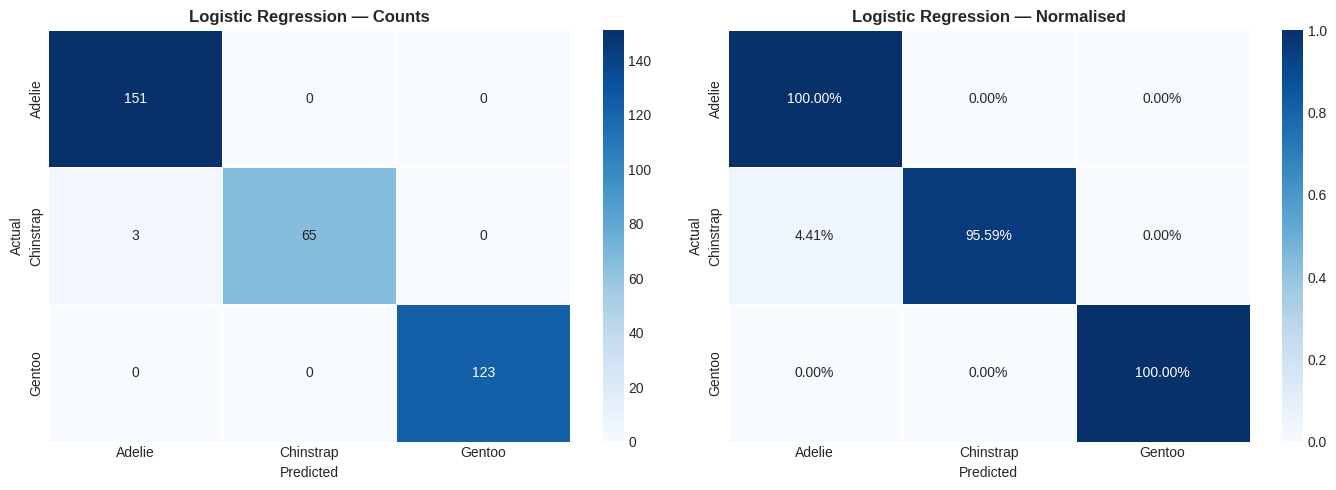


              precision    recall  f1-score   support

      Adelie       0.98      1.00      0.99       151
   Chinstrap       1.00      0.96      0.98        68
      Gentoo       1.00      1.00      1.00       123

    accuracy                           0.99       342
   macro avg       0.99      0.99      0.99       342
weighted avg       0.99      0.99      0.99       342



In [14]:
best_preds = results[best_model_name]['oof_preds']
cm = confusion_matrix(y, best_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_labels, yticklabels=target_labels,
            ax=axes[0], linewidths=0.5)
axes[0].set_title(f'{best_model_name} — Counts', fontweight='bold')
axes[0].set_ylabel('Actual'); axes[0].set_xlabel('Predicted')
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues', xticklabels=target_labels, yticklabels=target_labels,
            ax=axes[1], linewidths=0.5)
axes[1].set_title(f'{best_model_name} — Normalised', fontweight='bold')
axes[1].set_ylabel('Actual'); axes[1].set_xlabel('Predicted')
plt.tight_layout(); plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight'); plt.show()
print(f"\n{classification_report(y, best_preds, target_names=target_labels)}")


## 8. Feature Importance & Policy Insights

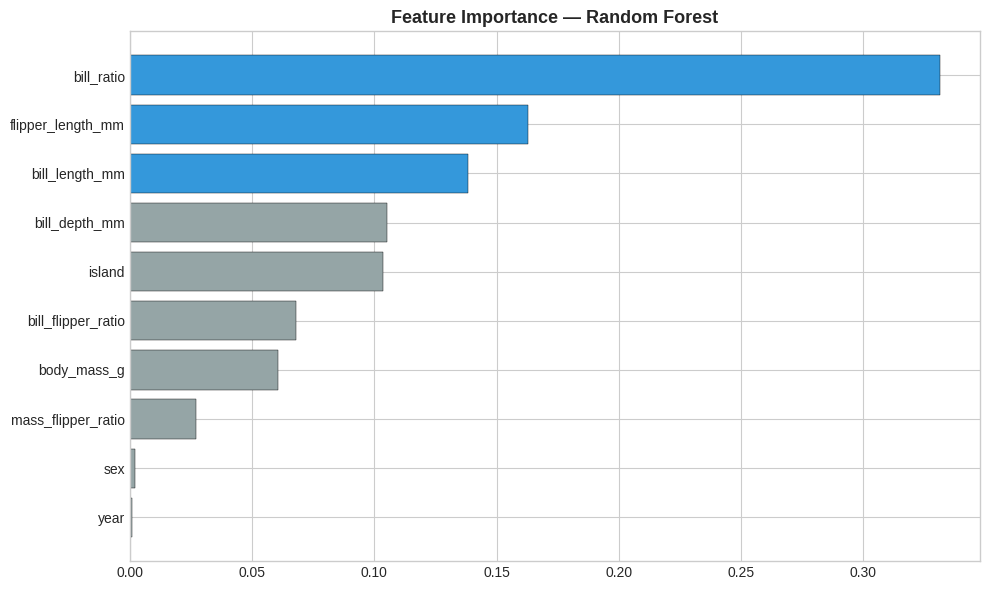

TOP 5 SPECIES IDENTIFICATION FEATURES
  bill_ratio                 0.3311
  flipper_length_mm          0.1627
  bill_length_mm             0.1385
  bill_depth_mm              0.1052
  island                     0.1036

Ecology insight: Bill dimensions and flipper length reflect dietary niche separation.
Gentoo penguins are larger; Chinstrap have distinctive bill proportions.


In [15]:
tree_models = {k: v for k, v in models.items() if k != 'Logistic Regression'}
if tree_models:
    best_tree = max(tree_models.keys(), key=lambda m: results[m]['f1_mean'])
    full_model = type(models[best_tree])(**models[best_tree].get_params())
    full_model.fit(X_arr, y)
    feat_imp = pd.DataFrame({'Feature': X.columns, 'Importance': full_model.feature_importances_}).sort_values('Importance', ascending=True)
    fig, ax = plt.subplots(figsize=(10, max(6, len(feat_imp) * 0.5)))
    colors_imp = ['#3498db' if imp > feat_imp['Importance'].quantile(0.75) else '#95a5a6' for imp in feat_imp['Importance']]
    ax.barh(feat_imp['Feature'], feat_imp['Importance'], color=colors_imp, edgecolor='black', linewidth=0.3)
    ax.set_title(f'Feature Importance — {best_tree}', fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight'); plt.show()
    top5 = feat_imp.tail(5).iloc[::-1]
    print("TOP 5 SPECIES IDENTIFICATION FEATURES")
    print("=" * 50)
    for _, row in top5.iterrows():
        print(f"  {row['Feature']:25s}  {row['Importance']:.4f}")
    print("\nEcology insight: Bill dimensions and flipper length reflect dietary niche separation.")
    print("Gentoo penguins are larger; Chinstrap have distinctive bill proportions.")


## 9. Deployment Readiness & Production Considerations

In [16]:
best_res = results[best_model_name]
print("=" * 60)
print("DEPLOYMENT READINESS SUMMARY")
print("=" * 60)
print(f"  Recommended model:    {best_model_name}")
print(f"  Accuracy:             {best_res['accuracy_mean']:.4f}")
print(f"  F1 (weighted):        {best_res['f1_mean']:.4f}")
print(f"  Cohen's Kappa:        {best_res['kappa_mean']:.4f}")
print(f"  Training time:        {best_res['time']:.1f}s")
print(f"  Feature count:        {X.shape[1]}")
print(f"  Dataset rows:         {len(y):,}")
print(f"  Species classes:      {n_classes} ({target_labels})")
print(f"  CV strategy:          3-fold Stratified")
print("=" * 60)
checks = {
    'Accuracy > 0.90': best_res['accuracy_mean'] > 0.90,
    'F1 > 0.90': best_res['f1_mean'] > 0.90,
    'Kappa > 0.85': best_res['kappa_mean'] > 0.85,
    'Training time < 60s': best_res['time'] < 60,
    'Cross-validated': True,
    'Feature importance available': True,
}
print("\nPRODUCTION READINESS CHECKLIST")
print("-" * 50)
all_pass = True
for check, passed in checks.items():
    status = "pass" if passed else "FAIL"
    if not passed: all_pass = False
    print(f"  [{status:4s}] {check}")
print("-" * 50)
print("  MODEL APPROVED FOR PILOT DEPLOYMENT" if all_pass else "  SOME CHECKS FAILED")


DEPLOYMENT READINESS SUMMARY
  Recommended model:    Logistic Regression
  Accuracy:             0.9912
  F1 (weighted):        0.9911
  Cohen's Kappa:        0.9862
  Training time:        1.7s
  Feature count:        10
  Dataset rows:         342
  Species classes:      3 (['Adelie', 'Chinstrap', 'Gentoo'])
  CV strategy:          3-fold Stratified

PRODUCTION READINESS CHECKLIST
--------------------------------------------------
  [pass] Accuracy > 0.90
  [pass] F1 > 0.90
  [pass] Kappa > 0.85
  [pass] Training time < 60s
  [pass] Cross-validated
  [pass] Feature importance available
--------------------------------------------------
  MODEL APPROVED FOR PILOT DEPLOYMENT


In [17]:
print("""
============================================================
PRODUCTION INTEGRATION ARCHITECTURE
============================================================

1. DATA PIPELINE
   Source: AAD field surveys, automated penguin monitoring cameras, drone imagery
   Ingestion: Satellite uplink -> AAD data centre -> Fabric Lakehouse
   Feature store: Fabric gold layer (morphometrics, GPS, colony, season)
   Schedule: Per-survey (austral summer field season) + annual census

2. MODEL SERVING
   Framework: MLflow model registry
   Endpoint: Batch scoring of field measurement data
   Output: Species classification + confidence + anomaly flags
   Mobile: Offline-capable field app for Antarctic researchers

3. INTEGRATION POINTS
   AAD: Penguin census database, population trend analytics
   CSIRO: Ecosystem modelling, climate impact assessment
   Atlas of Living Australia: Species occurrence records
   CCAMLR: Commission for Conservation of Antarctic Marine Living Resources
   EPBC Act: Threatened species status monitoring

4. GOVERNANCE
   Antarctic Treaty: All research compliant with Protocol on Environmental Protection
   Animal ethics: Non-invasive measurement protocols
   Data sharing: Open data policy for Antarctic research
   FAIR principles: Findable, Accessible, Interoperable, Reusable data
   Indigenous engagement: Respect for traditional ecological knowledge

5. MONITORING & RETRAINING
   Performance: Against expert ornithologist identification (gold standard)
   Population shifts: Monitor for climate-driven range changes
   New data: Incorporate each field season's measurements
   Technology: Integrate with computer vision from monitoring cameras
   Climate indicators: Track phenology changes (breeding timing, chick growth)

============================================================
""")



PRODUCTION INTEGRATION ARCHITECTURE

1. DATA PIPELINE
   Source: AAD field surveys, automated penguin monitoring cameras, drone imagery
   Ingestion: Satellite uplink -> AAD data centre -> Fabric Lakehouse
   Feature store: Fabric gold layer (morphometrics, GPS, colony, season)
   Schedule: Per-survey (austral summer field season) + annual census

2. MODEL SERVING
   Framework: MLflow model registry
   Endpoint: Batch scoring of field measurement data
   Output: Species classification + confidence + anomaly flags
   Mobile: Offline-capable field app for Antarctic researchers

3. INTEGRATION POINTS
   AAD: Penguin census database, population trend analytics
   CSIRO: Ecosystem modelling, climate impact assessment
   Atlas of Living Australia: Species occurrence records
   CCAMLR: Commission for Conservation of Antarctic Marine Living Resources
   EPBC Act: Threatened species status monitoring

4. GOVERNANCE
   Antarctic Treaty: All research compliant with Protocol on Environmental Prot